In [93]:
import numpy as np
import matplotlib.pylab as plt
from scipy.optimize import curve_fit
import pandas as pd
from scipy.stats import linregress
from scipy.interpolate import interp1d

In [94]:
abs_temp = 273.15
def true_temp(measured_temp, e):
    temp = ((measured_temp+273.15)**4/0.85/e)**(1/4) - 273.15
    return temp 

In [95]:
S = (1.15/2)**2*np.pi#+1.15*0.2*np.pi
S

1.0386890710931251

In [96]:
reaction_record = pd.read_excel('reaction_record.xlsx', engine='openpyxl')
reaction_record.head()
temp = reaction_record['convert temp K']
measure_temp = reaction_record['measured temp C (apparent)']
mass_in = reaction_record['mass increase g']
time = reaction_record['react time min']
surf = reaction_record['surface area cm2']
pressure = reaction_record['CO2 pressure mbar']/1000
current = reaction_record['Amps']

## reaction rate calculation

/var/folders/d5/pzrlnbqs48j3yz2zvf9xjt6m0000gn/T/ipykernel_10073/1554480640.py:107: RuntimeWarning: divide by zero encountered in divide
  return 10000 / x
/var/folders/d5/pzrlnbqs48j3yz2zvf9xjt6m0000gn/T/ipykernel_10073/1554480640.py:107: RuntimeWarning: divide by zero encountered in divide
  return 10000 / x


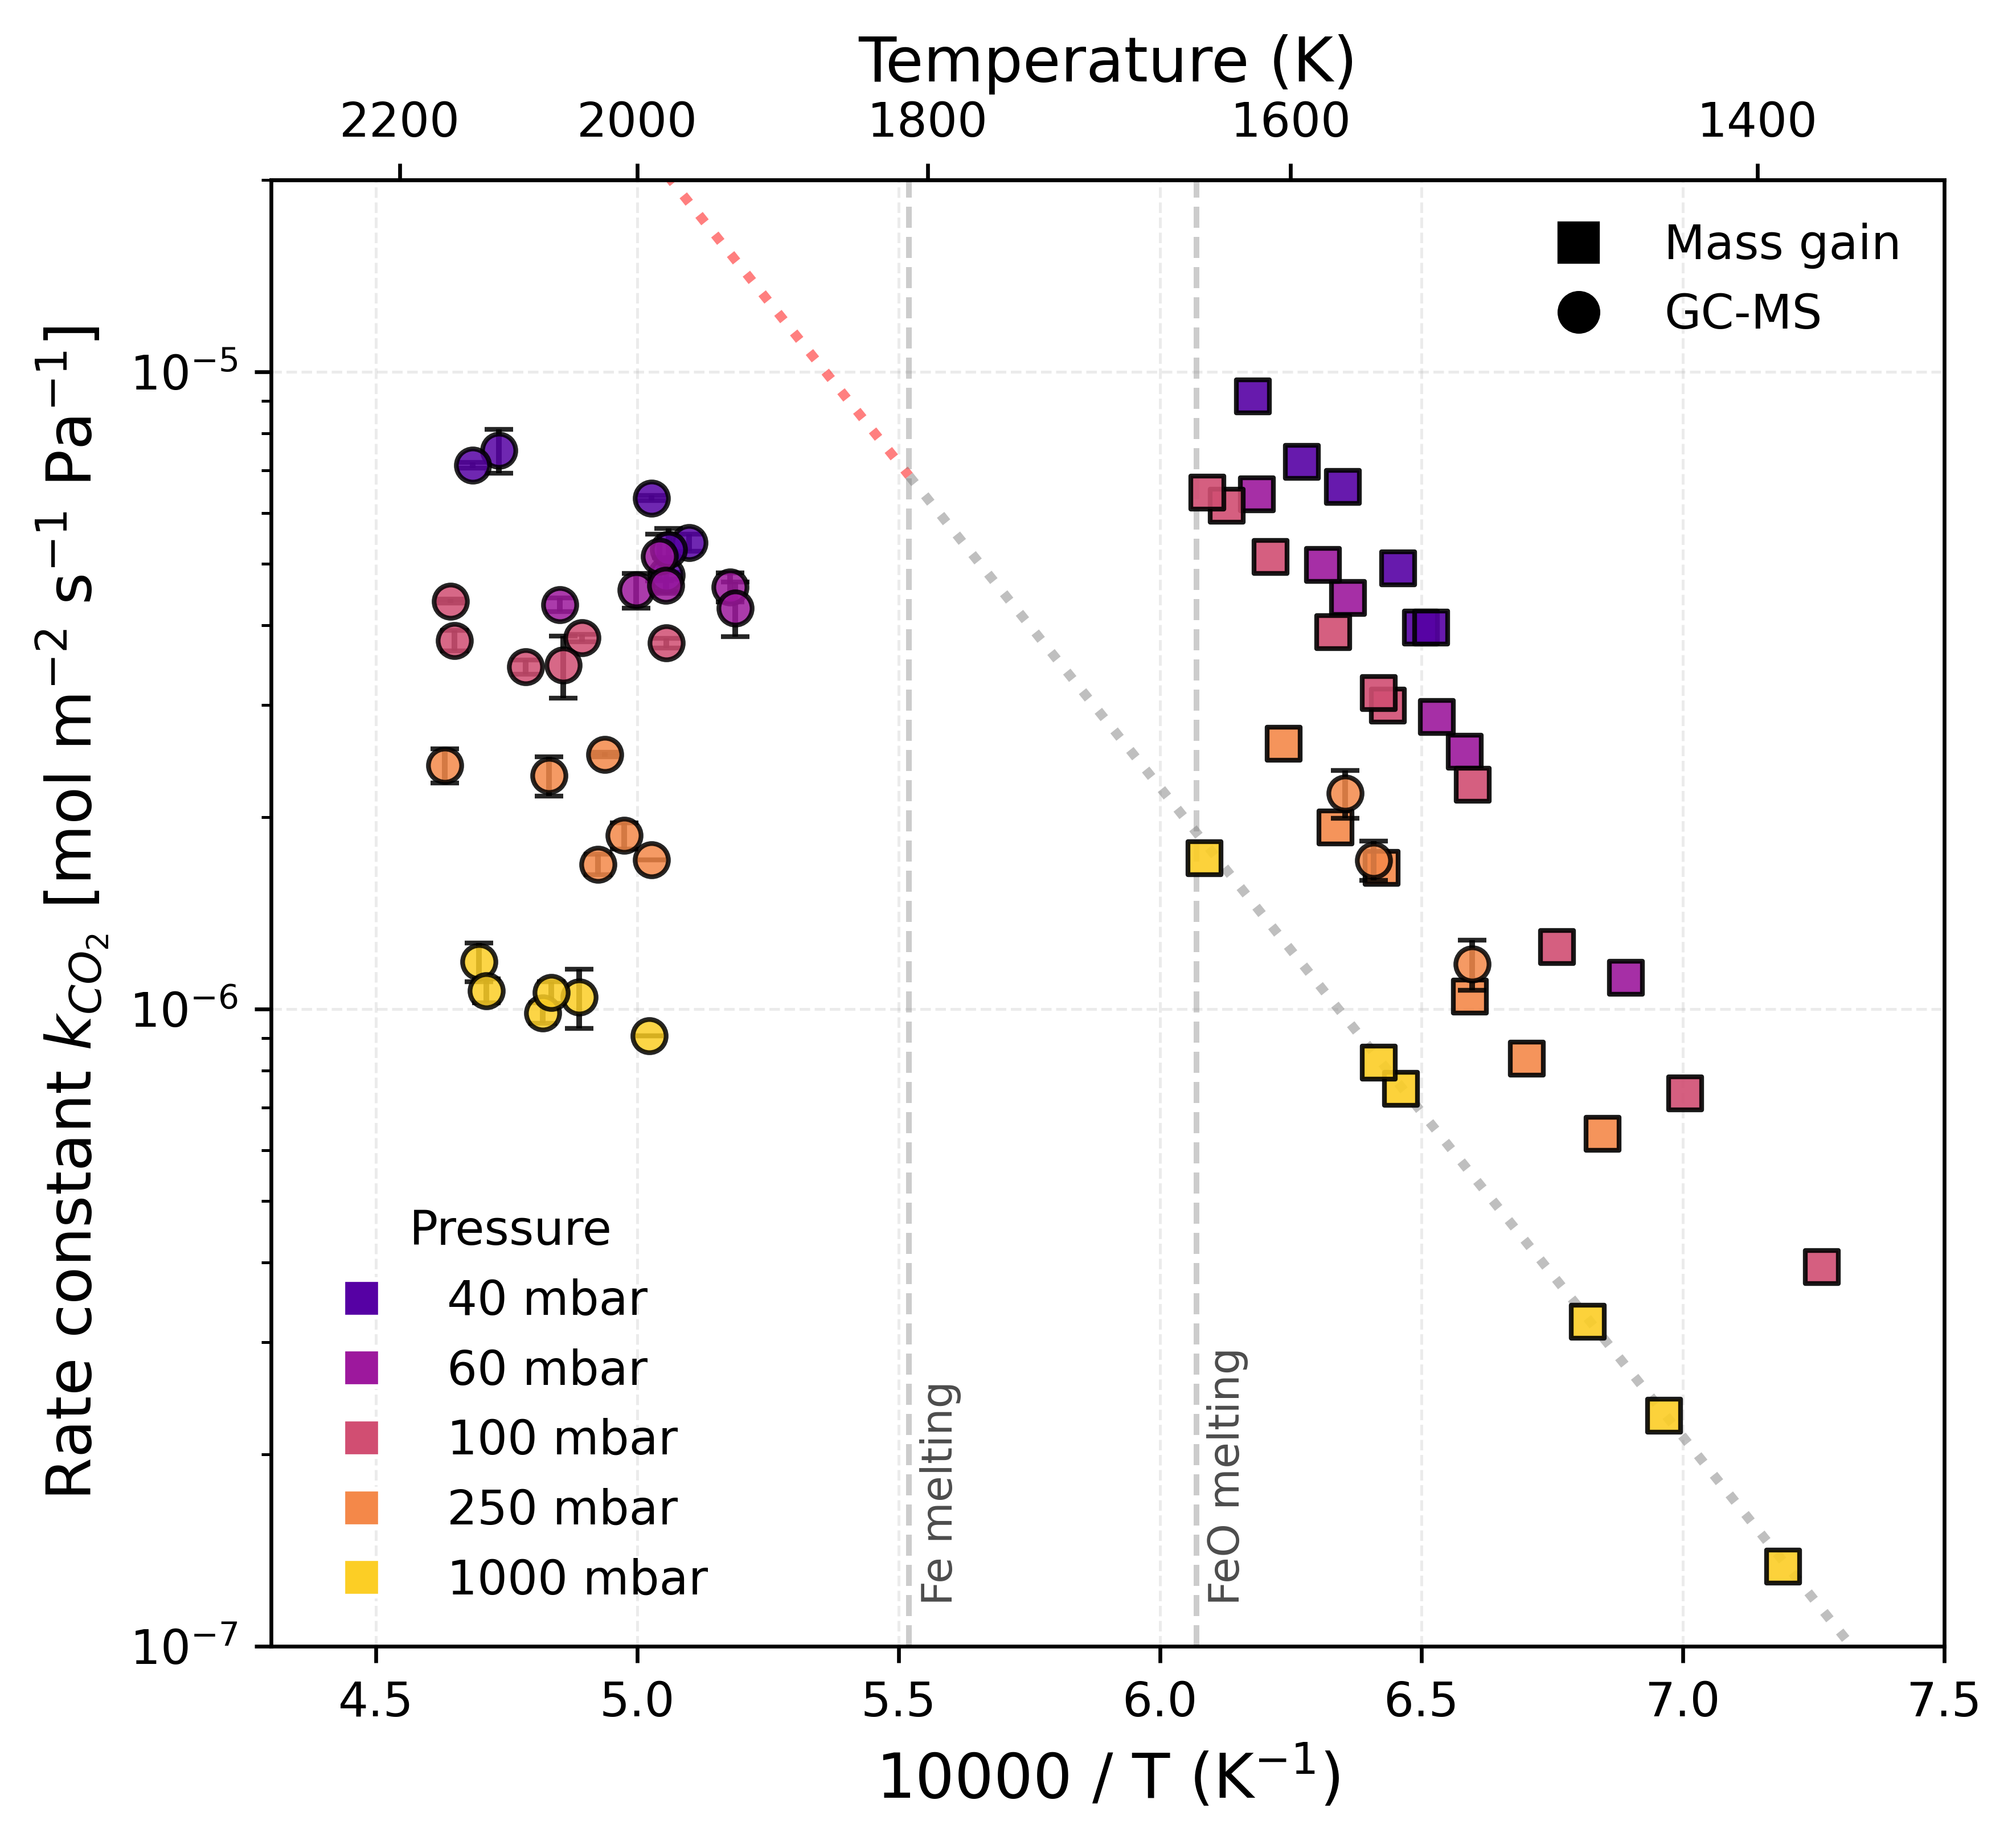

In [113]:
from matplotlib.lines import Line2D

reaction_record = pd.read_excel('reaction_record.xlsx',engine='openpyxl',sheet_name=0)
pressure_groups = dict(tuple(reaction_record.groupby('CO2 pressure mbar')))
pressures = [40, 60, 100, 250, 1000]
colors = plt.cm.plasma(np.linspace(0.15, 0.9, len(pressures)))
fig, ax1 = plt.subplots(figsize=(6, 5.5), dpi=600)

#################################################
# 1000 mbar fit
#################################################

df_1000 = pressure_groups[1000]
T_K = df_1000['convert temp K'].to_numpy()
mass_in = df_1000['mass increase g'].to_numpy()
time_min = df_1000['react time min'].to_numpy()
area_cm2 = df_1000['surface area cm2'].to_numpy()

rate = (mass_in / area_cm2 / time_min/ 16 / 1000 / 100 / 60 * 10000)
x = 10000 / T_K
coef = np.polyfit(x, np.log(rate), 1)
x_fit = np.linspace(5.52, 7.5, 200)
y_fit = np.exp(np.polyval(coef, x_fit))
x_fit2 = np.linspace(4.2, 5.52, 200)
y_fit2 = np.exp(np.polyval(coef, x_fit2))

ax1.plot(x_fit,y_fit,color='gray',lw=2,ls=':',alpha=0.5)

ax1.plot(x_fit2,y_fit2,color='red',lw=2,ls=':',alpha=0.5)

#################################################
# melting lines
#################################################

for xpos, txt in zip([5.52, 6.07],['Fe melting', 'FeO melting']):
    ax1.axvline(x=xpos,ls='--',c='gray',alpha=0.4,lw=1.2)
    ax1.text(xpos + 0.02,1.2e-7,txt,fontsize=9,rotation=90,alpha=0.7)

#################################################
# MASS GAIN DATA
#################################################

for i, p in enumerate(pressures):

    df_temp = pressure_groups[p]

    T_K = df_temp['convert temp K'].to_numpy()
    mass_in = df_temp['mass increase g'].to_numpy()
    time_min = df_temp['react time min'].to_numpy()
    area_cm2 = df_temp['surface area cm2'].to_numpy()
    rate = (mass_in / area_cm2 / time_min / 16 / p / 100 / 60 * 10000)
    x = 10000 / T_K

    # VERY IMPORTANT
    # small x jitter to avoid overlap
    jitter = np.random.normal(0, 0.015, len(x))

    ax1.scatter(x + jitter,rate,marker='s',s=50,facecolor=colors[i],edgecolor='black',linewidth=1,alpha=0.9,zorder=3)

#################################################
# GC-MS DATA
#################################################

reaction_record = pd.read_excel('',engine='openpyxl', sheet_name=0)
pressure_groups = dict(tuple( reaction_record.groupby('CO2 pressure mbar')))
Chamber = 12.6 / 24 #24 L/mol - chamber - mol under 1bar
for i, p in enumerate(pressures):

    df_temp = pressure_groups[p]

    T_K = df_temp['convert temp K']
    CO = df_temp['CO ppm']
    CO_error = df_temp['sigma']

    time_s = df_temp['react time s']
    area_cm2 = df_temp['surface area cm2']

    CO2_total = Chamber * p / 1000 # mol

    O_total = CO2_total * CO / 1e6 * 16 #g
    O_std = CO2_total * CO_error / 1e6 * 2 * 16 #g

    rate = (O_total / area_cm2 / time_s / 16 / p / 100 * 10000) #mol/m2/s/pa
    sigma = (O_std / area_cm2 / time_s / 16 / p / 100 * 10000 )
    
    x = 10000 / T_K

    jitter = np.random.normal(0, 0.015, len(x))

    ax1.errorbar(x + jitter,rate,yerr=sigma,fmt='o',markersize=7,
        color=colors[i],ecolor='black',elinewidth=1.2,capsize=3,markeredgecolor='black',
        markeredgewidth=1,alpha=0.85,zorder=4)

#################################################
# AXIS
#################################################

ax1.set_yscale('log')
ax1.set_ylabel(r'Rate constant $k_{CO_2}$ [mol m$^{-2}$ s$^{-1}$ Pa$^{-1}$]', fontsize=13)
ax1.set_xlabel( r'10000 / T (K$^{-1}$)',fontsize=13)

#################################################
# TOP TEMPERATURE AXIS
#################################################

def invT(x):
    return 10000 / x

ax2 = ax1.secondary_xaxis('top',functions=(invT, invT))

ax2.set_xlabel('Temperature (K)',fontsize=13)

ax2.tick_params(labelsize=10)

#################################################
# LIMITS
#################################################

ax1.set_xlim(4.3, 7.5)
ax1.set_ylim(1e-7, 2e-5)

ax1.tick_params(labelsize=10)

#################################################
# GRID
#################################################
ax1.grid(alpha=0.25,linestyle='--',linewidth=0.6)
#################################################
# CUSTOM LEGEND
#################################################

pressure_handles = [
    Line2D(
        [0], [0],
        marker='s',
        color='w',
        markerfacecolor=colors[i],
        markersize=8,
        label=f'{p} mbar'
    )
    for i, p in enumerate(pressures)
]

type_handles = [
    Line2D([0], [0],marker='s',color='black',linestyle='None',markersize=8,label='Mass gain'),
    Line2D([0], [0],marker='o',color='black',linestyle='None',markersize=8,label='GC-MS')
]

legend1 = ax1.legend(handles=pressure_handles,title='Pressure',fontsize=10,frameon=False,loc='lower left')
legend2 = ax1.legend(handles=type_handles,fontsize=10,frameon=False,loc='upper right')

ax1.add_artist(legend1)

#################################################
plt.tight_layout()
plt.savefig('results.pdf',bbox_inches='tight')
plt.show()

In [158]:
from scipy.stats import linregress
import numpy as np

reaction_record = pd.read_excel('NewMelt_reaction_record.xlsx', engine='openpyxl', sheet_name=1)
pressure_groups = dict(tuple(reaction_record.groupby('CO2 pressure mbar')))
Chamber = 12.6 / 24

pressures = [40, 60, 100, 250, 1000]
colors = plt.cm.plasma(np.linspace(0.15, 0.9, len(pressures)))

# ─────────────────────────────────────────────────────────
# 策略 A：分压力单独 Arrhenius 拟合
# 适合 R² > 0.5 的组；R² 太低的组不画拟合线
# ─────────────────────────────────────────────────────────

fit_results = {}

for i, p in enumerate(pressures):
    df_temp = pressure_groups[p]

    T_K      = df_temp['convert temp K'].to_numpy()
    CO       = df_temp['CO ppm'].to_numpy()
    CO_error = df_temp['sigma'].to_numpy()
    time_s   = df_temp['react time s'].to_numpy()
    area_cm2 = df_temp['surface area cm2'].to_numpy()

    CO2_total = Chamber * p / 1000
    O_total   = CO2_total * CO / 1e6 * 16
    O_std     = CO2_total * CO_error / 1e6 * 2 * 16

    rate  = O_total  / area_cm2 / time_s / 16 / p / 100 * 10000
    sigma = O_std    / area_cm2 / time_s / 16 / p / 100 * 10000

    x = 10000 / T_K
    y = np.log(rate)

    slope, intercept, r, _, se = linregress(x, y)
    R2  = r ** 2
    Ea  = -slope * 8.314 * 10000 / 1000   # kJ/mol
    lnA = intercept

    fit_results[p] = dict(slope=slope, intercept=intercept, R2=R2, Ea=Ea, lnA=lnA, n=len(T_K))

    # 只画 R² > 0.4 的拟合线，避免误导
    if R2 > 0.4:
        x_fit = np.linspace(x.min() - 0.05, x.max() + 0.05, 100)
        y_fit = np.exp(slope * x_fit + intercept)
        ax1.plot(x_fit, y_fit,
                 color=colors[i], lw=1.4, ls='--', alpha=0.6, zorder=2)

all_rates = []
for p in pressures:
    df_temp  = pressure_groups[p]
    T_K      = df_temp['convert temp K'].to_numpy()
    CO       = df_temp['CO ppm'].to_numpy()
    time_s   = df_temp['react time s'].to_numpy()
    area_cm2 = df_temp['surface area cm2'].to_numpy()
    CO2_total = Chamber * p / 1000
    O_total   = CO2_total * CO / 1e6 * 16
    rate = O_total / area_cm2 / time_s / 16 / p / 100 * 10000
    print('average:', np.average(rate), 'at ',p)
    print('2sigma:', 2*np.std(rate), 'at', p)
    all_rates.extend(rate.tolist())

mean_rate   = np.mean(all_rates)
std_rate    = np.std(all_rates)
x_span      = np.array([4.3, 5.52])  


print(f"\n{'P (mbar)':>10} {'n':>4} {'Ea (kJ/mol)':>12} {'ln(A)':>8} {'R²':>6}")
print("-" * 46)
for p in pressures:
    r = fit_results[p]
    flag = "  ← low R², no fit line" if r['R2'] < 0.4 else ""
    print(f"{p:>10} {r['n']:>4} {r['Ea']:>12.1f} {r['lnA']:>8.2f} {r['R2']:>6.3f}{flag}")

print(f"\nAll-molten mean rate = {mean_rate:.2e} ± {std_rate:.2e} mol/m²/s/Pa")

average: 6.073550828990452e-06 at  40
2sigma: 2.005687972995628e-06 at 40
average: 4.575186231174341e-06 at  60
2sigma: 5.646907540965563e-07 at 60
average: 3.7707232042949738e-06 at  100
2sigma: 6.112985184785249e-07 at 100
average: 2.085786167244433e-06 at  250
2sigma: 6.744003829333601e-07 at 250
average: 1.0423350232865125e-06 at  1000
2sigma: 1.6987382409987283e-07 at 1000

  P (mbar)    n  Ea (kJ/mol)    ln(A)     R²
----------------------------------------------
        40    6         73.4    -7.67  0.828
        60    6         -1.3   -12.38  0.001  ← low R², no fit line
       100    6         21.3   -11.26  0.195  ← low R², no fit line
       250    6         62.2    -9.44  0.317  ← low R², no fit line
      1000    6         51.3   -10.80  0.751

All-molten mean rate = 3.51e-06 ± 1.85e-06 mol/m²/s/Pa


A: 4.459296399876678e-05
n: -0.5463647904323355
R^2; 0.9966722889545286


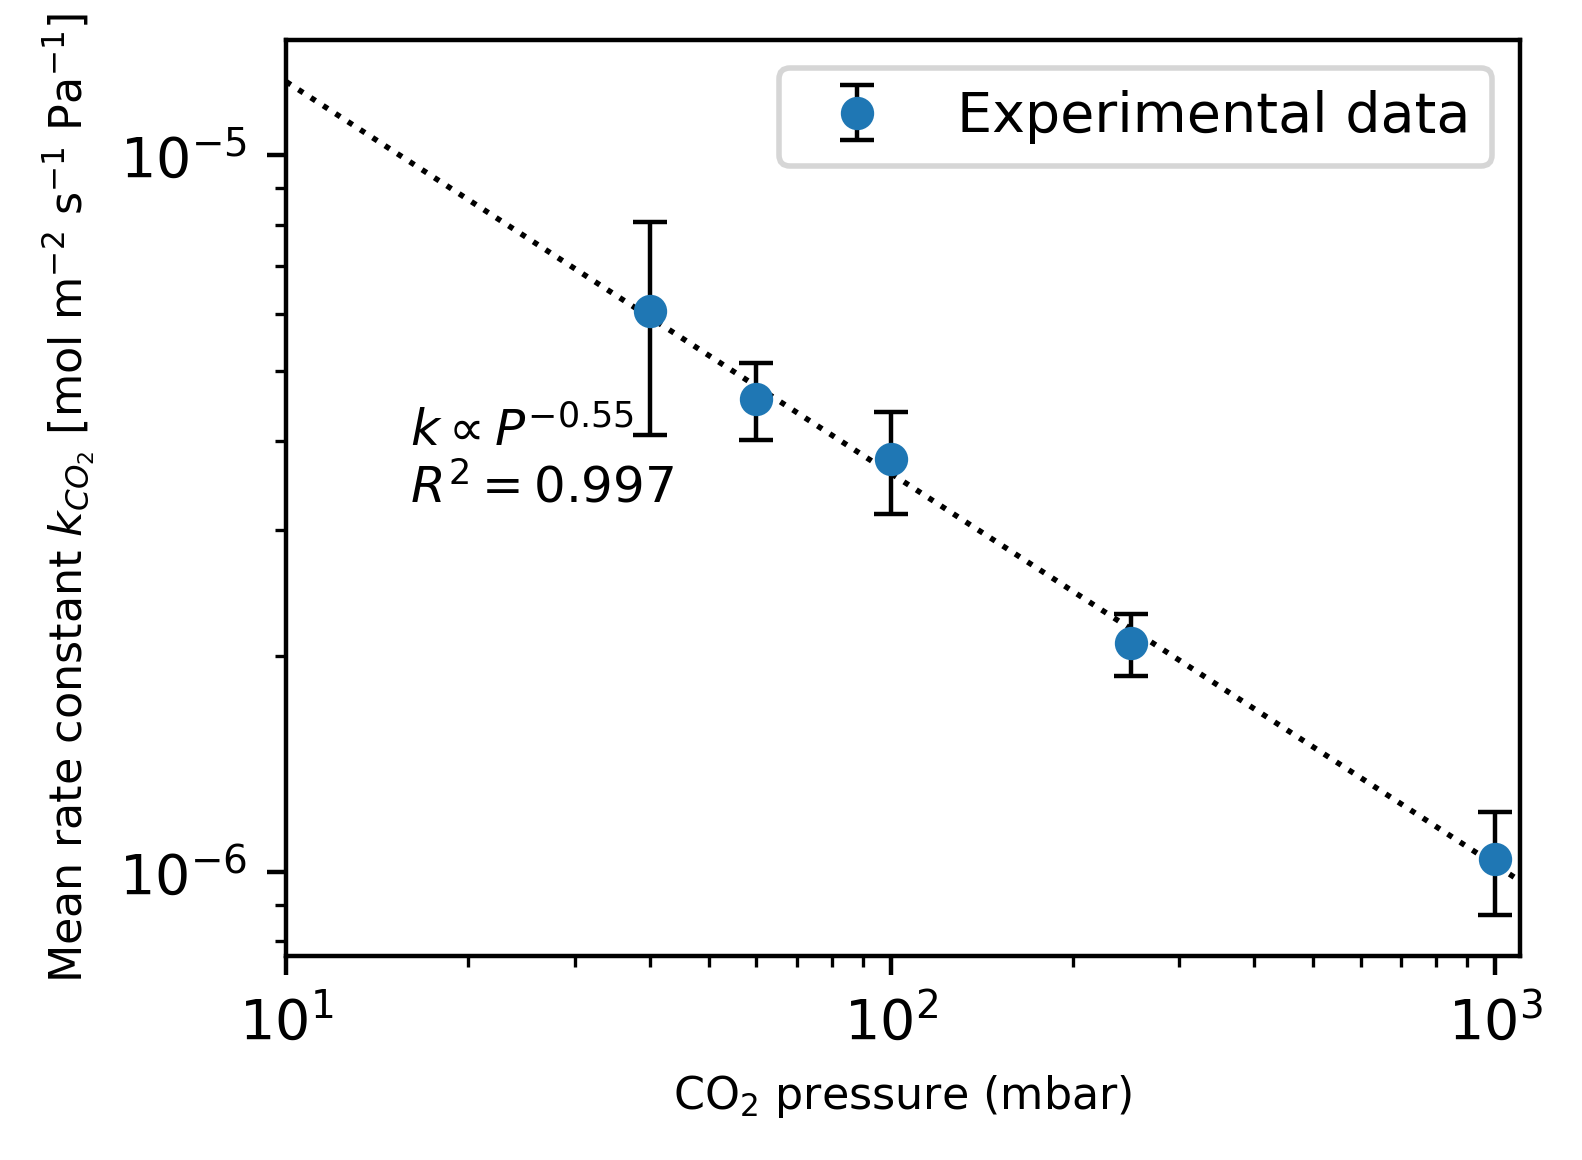

In [168]:
from scipy.stats import linregress
pressures = np.array([40,60,100,250,1000])
mean_rates = np.array([6.0734e-06, 4.5752e-06, 3.7707e-06, 2.0858e-6, 1.0423e-06])
std2_rates = np.array([2.0057e-06, 5.6469e-07, 6.1130e-7, 2.0858e-7, 1.699e-07])
log_p = np.log10(pressures)
log_r = np.log10(mean_rates)

slope, intercept, r, pval, se = linregress(log_p, log_r)
n = slope
A = 10 ** intercept
print('A:',A )
print('n:', n)
print('R^2;', r**2)
fig, ax = plt.subplots(figsize=(4, 3),dpi=400)
ax.errorbar(pressures, mean_rates,
            yerr=std2_rates,
            fmt='o', ms=5,
            ecolor='black', elinewidth=0.8,
            capsize=3, capthick=0.8,
            linewidth=0.8,zorder=3,
            label = 'Experimental data')

x = np.linspace(10,1100,100)
y = A * x ** n
ax.plot(x,y,c = 'k', lw = 1 , ls = ':', label = '')
ax.set_xlabel(r'CO$_2$ pressure (mbar)',fontsize=8)
ax.set_ylabel(r'Mean rate constant $k_{CO_2}$ [mol m$^{-2}$ s$^{-1}$ Pa$^{-1}$]',fontsize=8)
ax.text(0.1,0.6,
    rf'$k \propto P^{{{n:.2f}}}$' '\n'
    rf'$R^2 = {r**2:.3f}$',
    transform=ax.transAxes,
    fontsize=9,
    va='top'
)
plt.yscale('log')
plt.xscale('log')
plt.tight_layout()
plt.legend()
plt.xlim([10,1100])
fig.savefig('Summary.pdf')